In [2]:
# step 1: imports
# importing basically everything upfront so we don't have to do it later
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn stuff
from sklearn.utils import resample # note: video said 'resampling' but that throws an error, it's just resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# models we might use
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# metric stuff to see if models actually work
from sklearn.metrics import classification_report, accuracy_score, recall_score
from sklearn.metrics import precision_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error, r2_score

import statsmodels.api as sm

(1215745, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB
None
              count      mean       std      min       25%       50%  \
alx       1215745.0  1.494200  3.826485 -22.1460   0.14131  1.308900   
aly

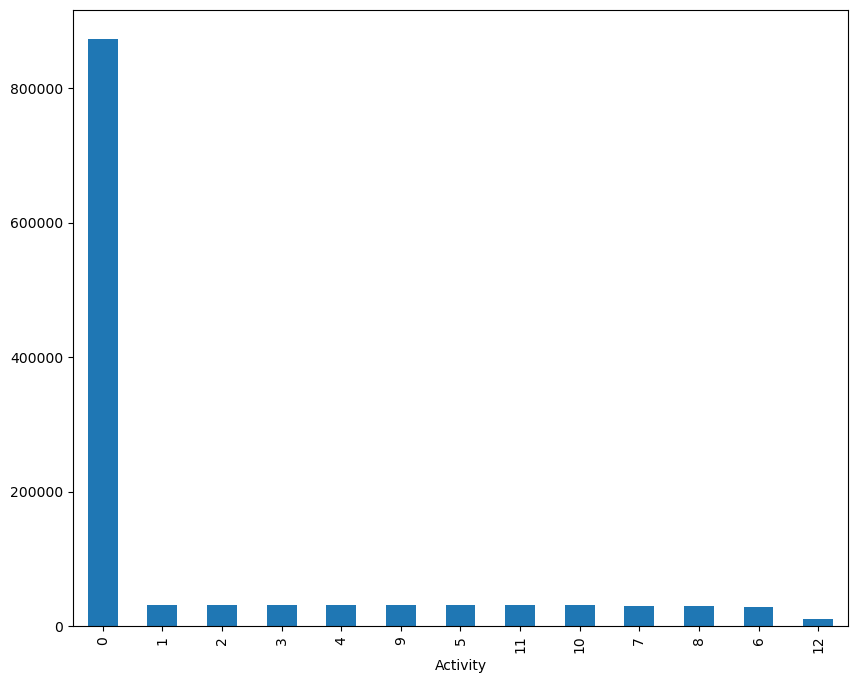

383195


In [6]:
# loading the mhealth dataset (he typed interactive python initially lol)
data_frame = pd.read_csv('/home/artifex/Machine-Learning/Projects/Human_action/mhealth_raw_data.csv')

# just checking what we are dealing with. shape should be massive (like 1.2 mil rows)
print(data_frame.shape)
print(data_frame.info())

# transpose to actually be able to read it without scrolling forever
print(data_frame.describe().T)

# making sure data isn't corrupt (expecting 0 for both)
print(data_frame.isnull().sum())
print(data_frame.duplicated().sum())

# plot the activity balance. spoiler: activity 0 (doing nothing) is way too huge
plt.figure(figsize=(10, 8))
data_frame['Activity'].value_counts().plot(kind='bar')
plt.show()

# gotta fix that imbalance. splitting activity 0 from the rest
data_activity_0 = data_frame[data_frame['Activity'] == 0]
data_activity_not_0 = data_frame[data_frame['Activity'] != 0]

# downsampling activity 0 to just 40k so it doesn't break the model
data_activity_0 = data_activity_0.sample(n=40000) 

# putting it all back together
data_frame = pd.concat([data_activity_0, data_activity_not_0])

# new shape should be way smaller, around 300k
print(len(data_frame))

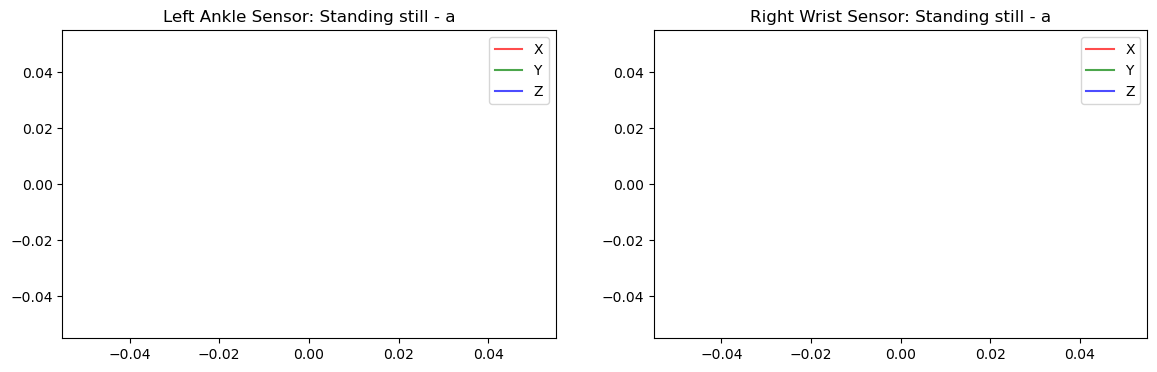

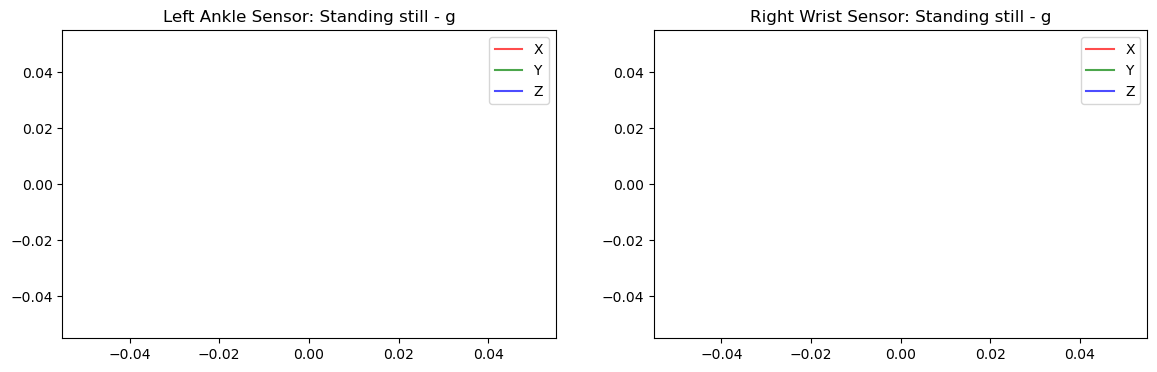

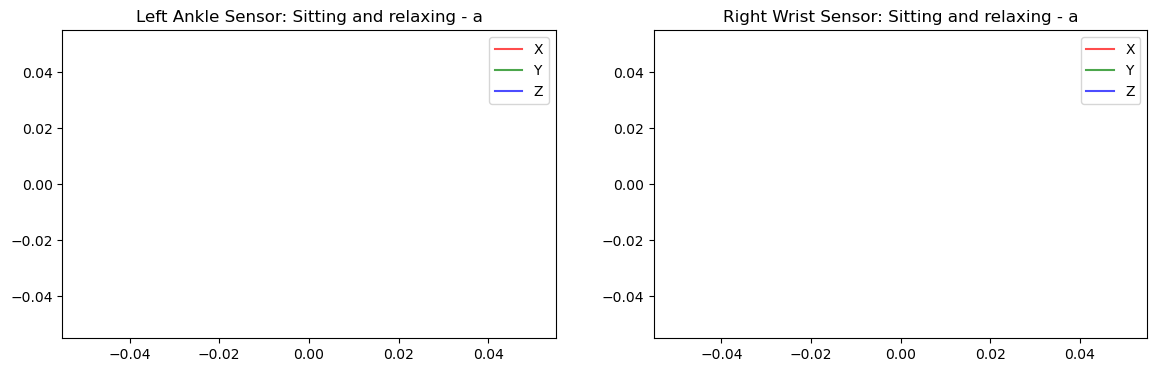

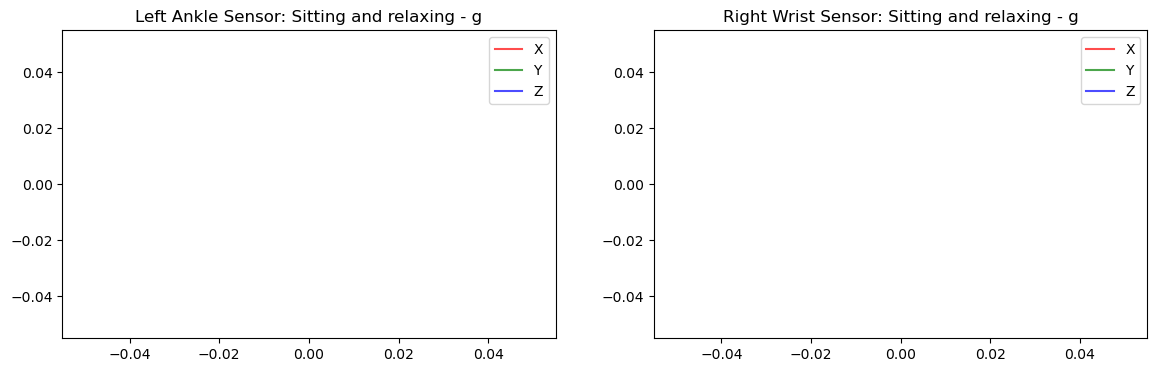

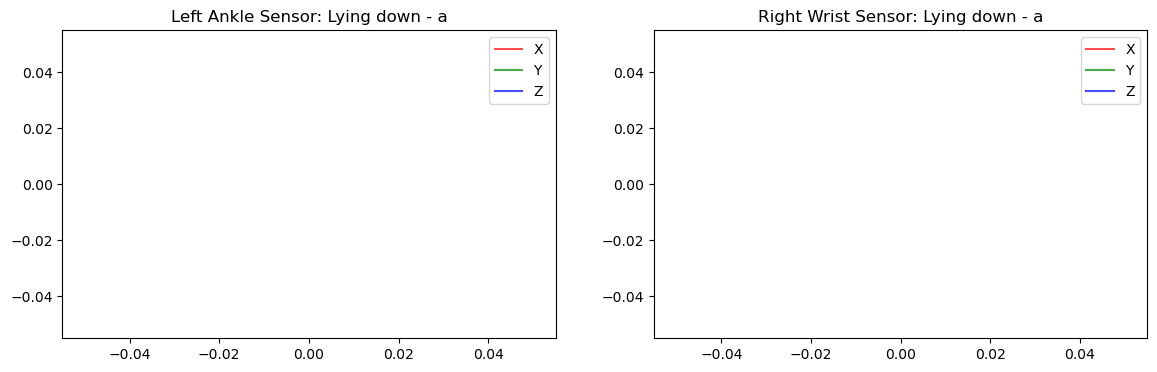

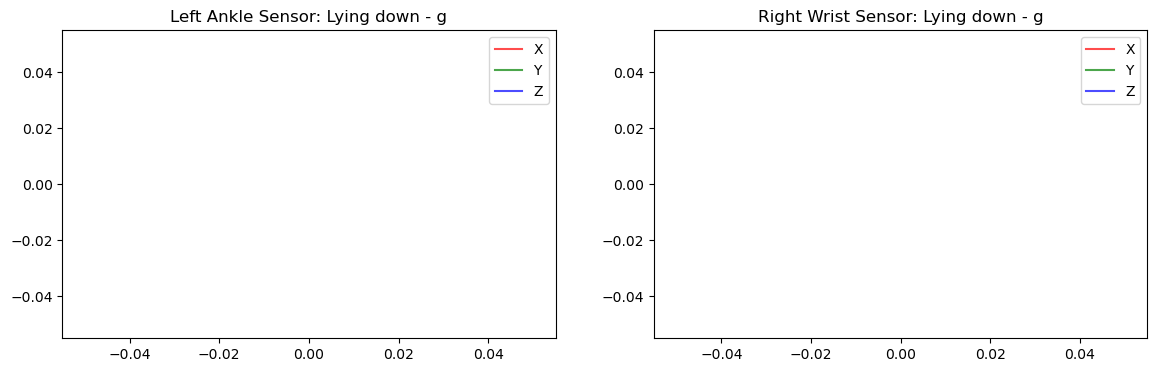

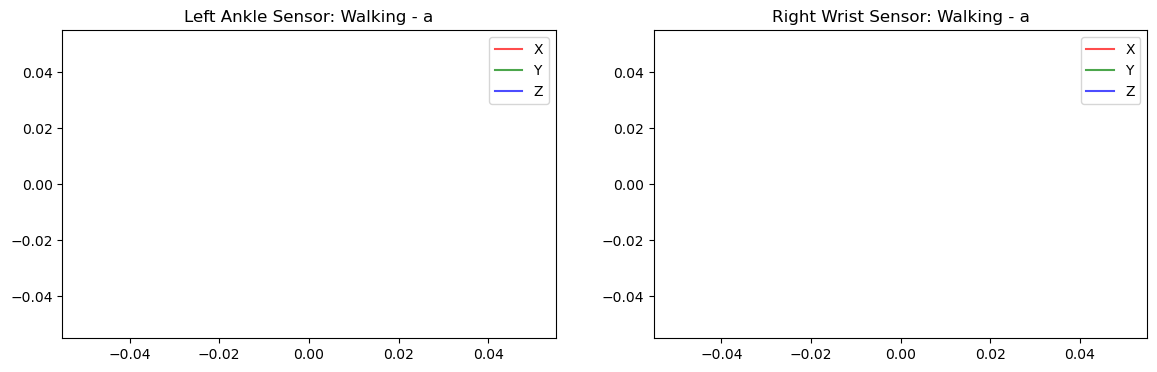

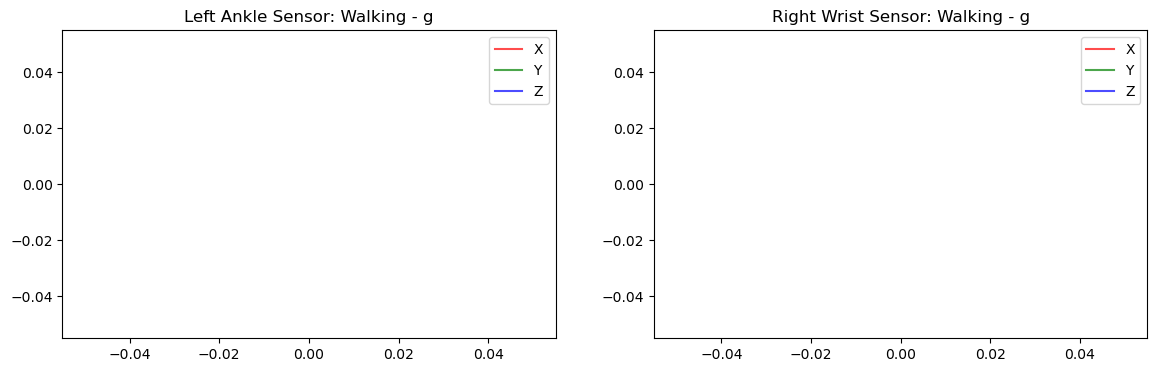

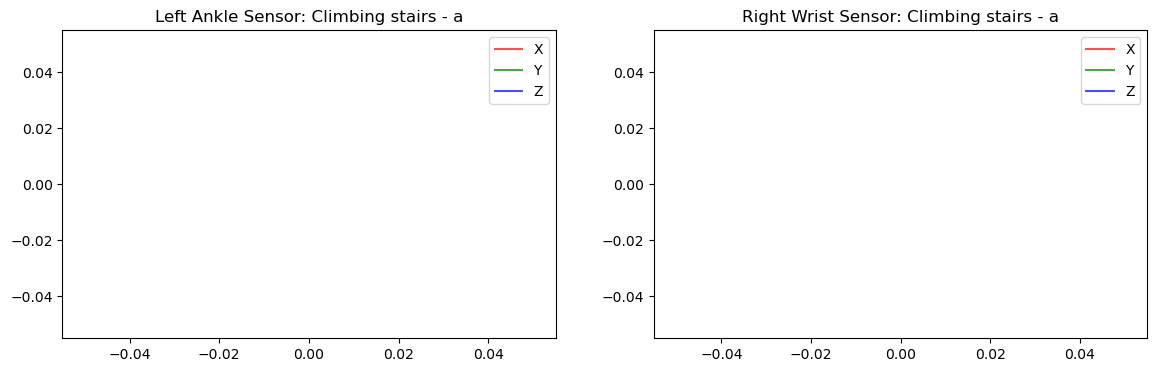

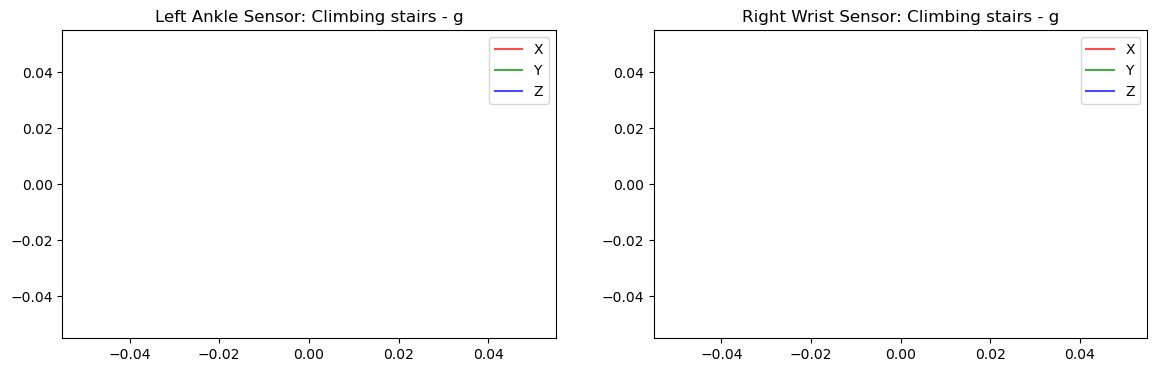

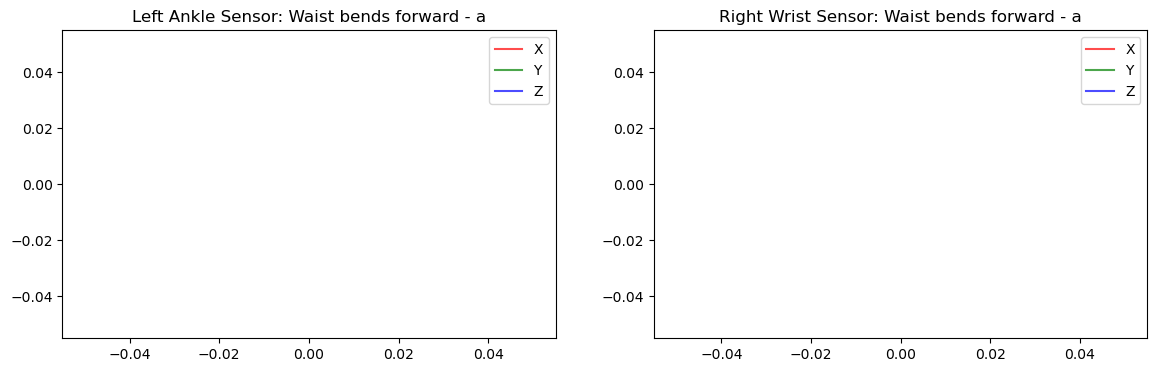

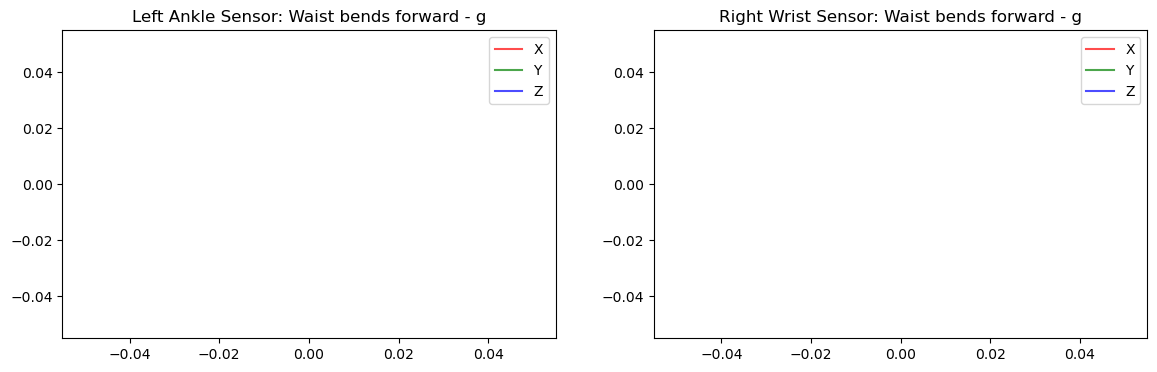

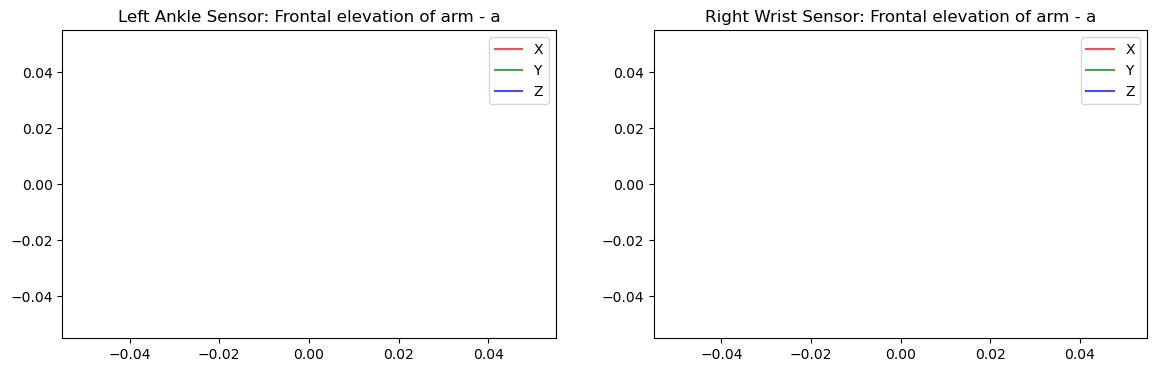

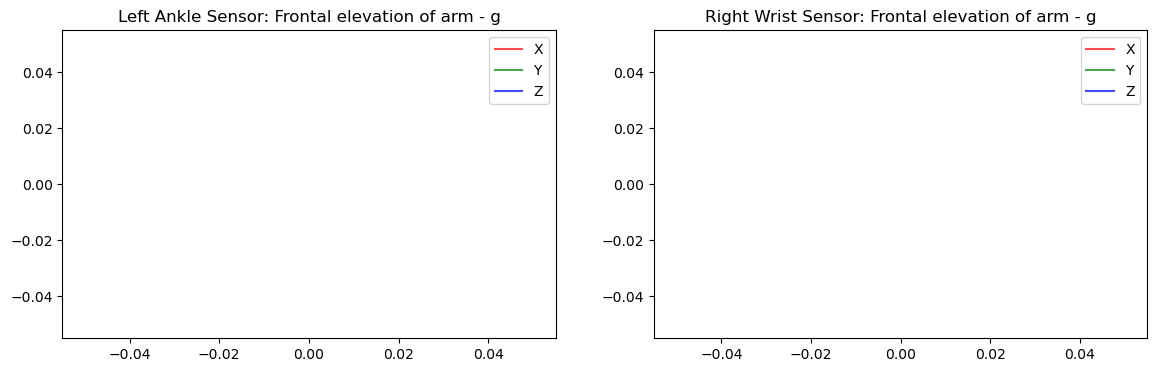

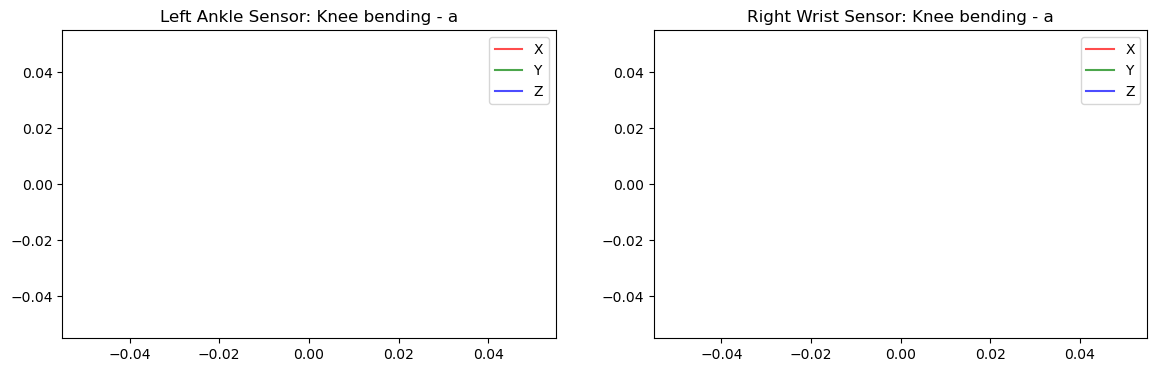

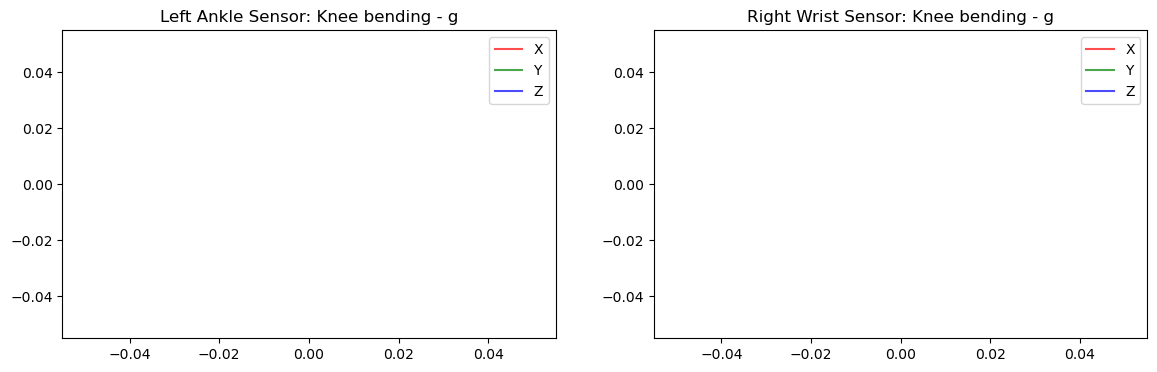

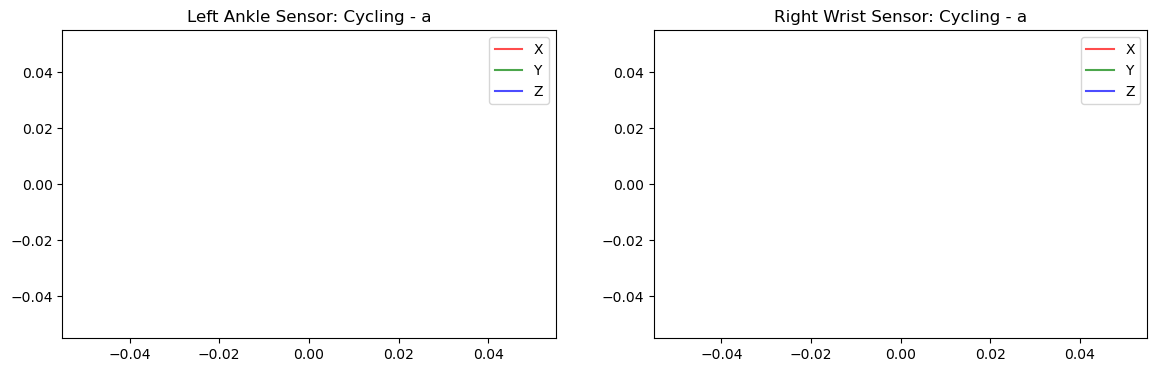

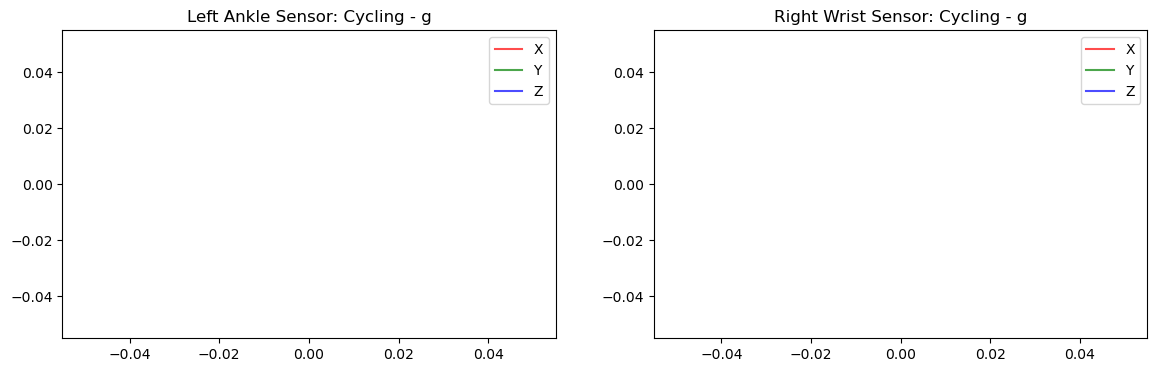

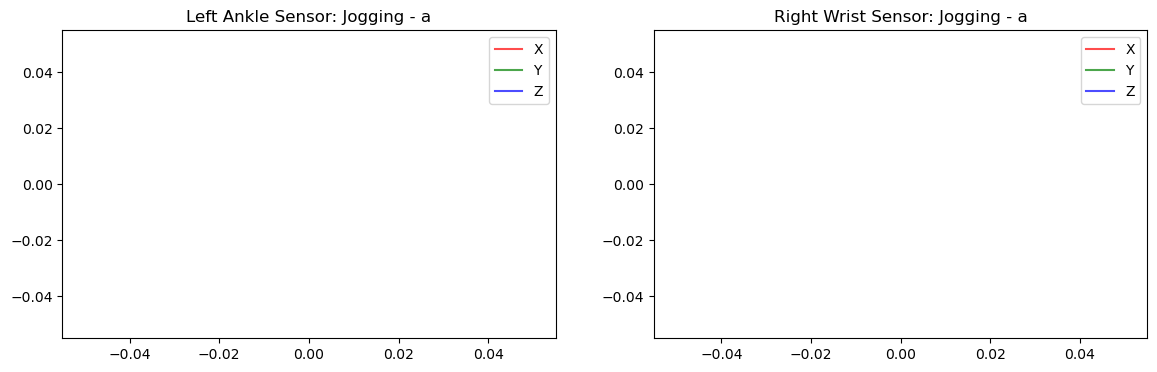

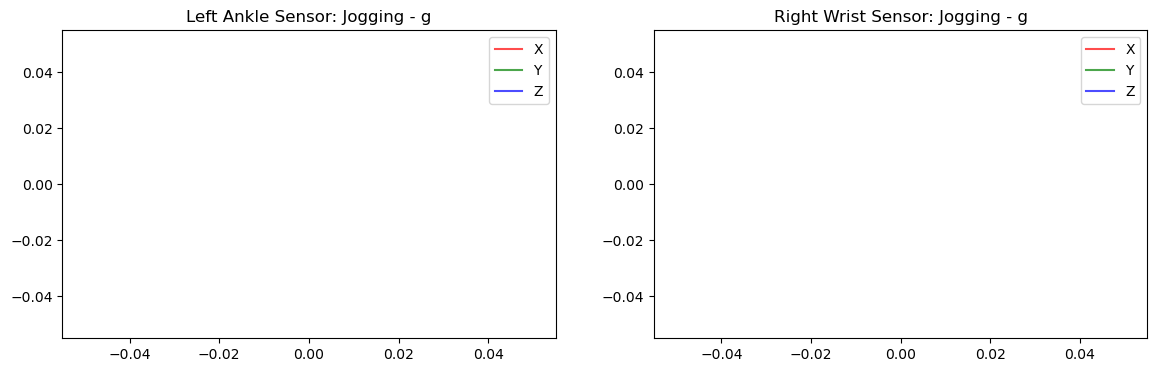

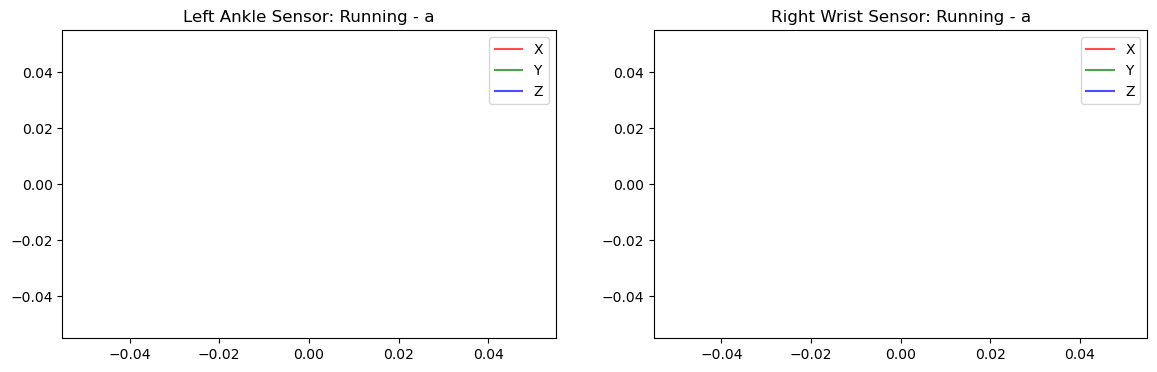

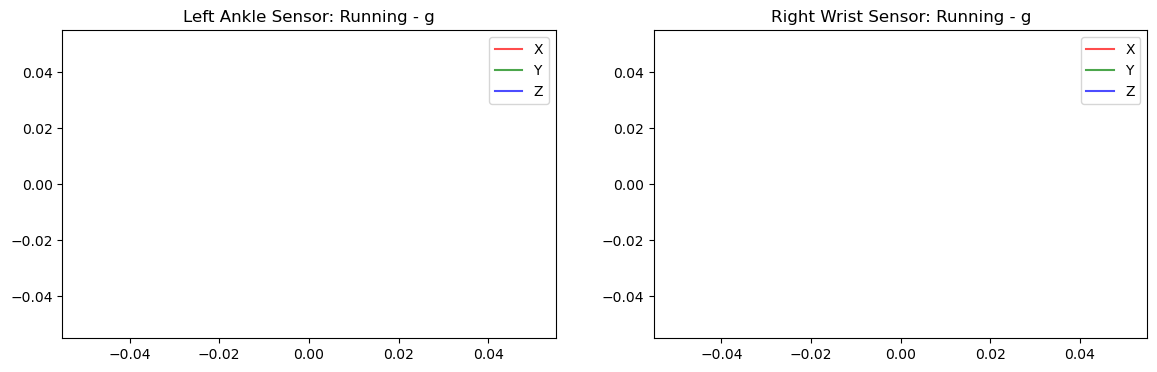

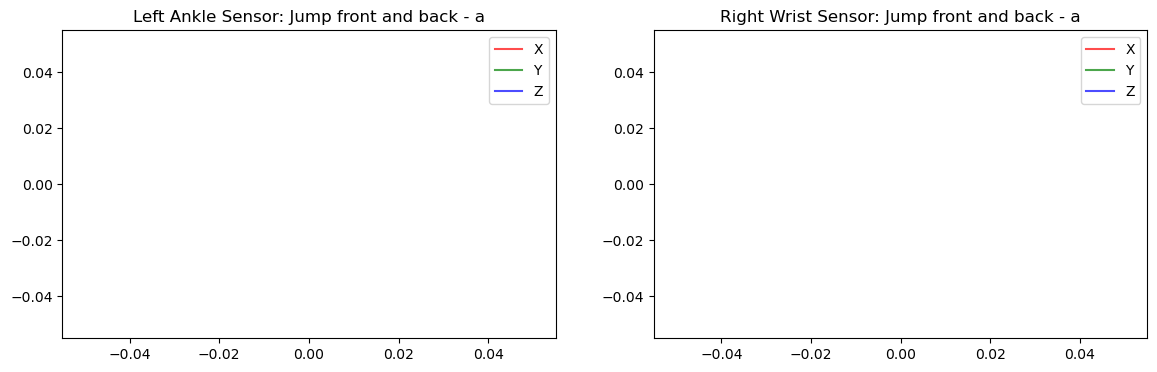

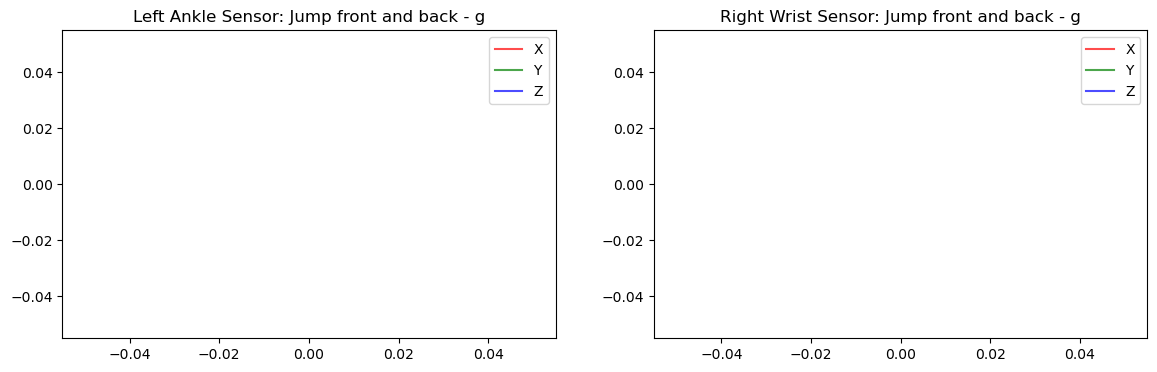

Shape after dropping outliers: (318969, 14)


In [9]:
# mapping dict so we actually know what the numbers mean later
activity_labels = pd.Series({
    0: 'None', 1: 'Standing still', 2: 'Sitting and relaxing', 3: 'Lying down', 
    4: 'Walking', 5: 'Climbing stairs', 6: 'Waist bends forward', 
    7: 'Frontal elevation of arm', 8: 'Knee bending', 9: 'Cycling', 
    10: 'Jogging', 11: 'Running', 12: 'Jump front and back'
})

# pulling subject 1 to visualize the sensor spikes 
subject_1 = data_frame[data_frame['subject'] == 1]

# checking acceleration (a) and gyroscope (g)
readings = ['a', 'g'] 

# crazy loop to plot 60 second sensor data for all 12 activities 
for i in range(1, 13):
    for r in readings:
        label = f"{activity_labels[i]} - {r}"
        
        # fig size 14x4 to match his screen
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # left ankle sensor plots (x, y, z)
        axes[0].plot(subject_1[subject_1['Activity'] == i][f'{r}lx'], label='X', color='red', alpha=0.7)
        axes[0].plot(subject_1[subject_1['Activity'] == i][f'{r}ly'], label='Y', color='green', alpha=0.7)
        axes[0].plot(subject_1[subject_1['Activity'] == i][f'{r}lz'], label='Z', color='blue', alpha=0.7)
        axes[0].set_title(f"Left Ankle Sensor: {label}")
        axes[0].legend()
        
        # right wrist sensor plots 
        axes[1].plot(subject_1[subject_1['Activity'] == i][f'{r}rx'], label='X', color='red', alpha=0.7)
        axes[1].plot(subject_1[subject_1['Activity'] == i][f'{r}ry'], label='Y', color='green', alpha=0.7)
        axes[1].plot(subject_1[subject_1['Activity'] == i][f'{r}rz'], label='Z', color='blue', alpha=0.7)
        axes[1].set_title(f"Right Wrist Sensor: {label}")
        axes[1].legend()
        
        plt.show()

# trying out outlier removal for top/bottom 1%
# doing this on a copy because sensor spikes are actually normal for jumping/running
data_frame1 = data_frame.copy()
features = data_frame1.columns[:-2] # drop activity and subject cols

for feature in features:
    lower_range = np.quantile(data_frame[feature], 0.01)
    upper_range = np.quantile(data_frame[feature], 0.99)
    
    # drop if outside 98% confidence interval
    outlier_index = data_frame1[(data_frame1[feature] > upper_range) | (data_frame1[feature] < lower_range)].index
    data_frame1 = data_frame1.drop(outlier_index, axis=0)

print("Shape after dropping outliers:", data_frame1.shape)

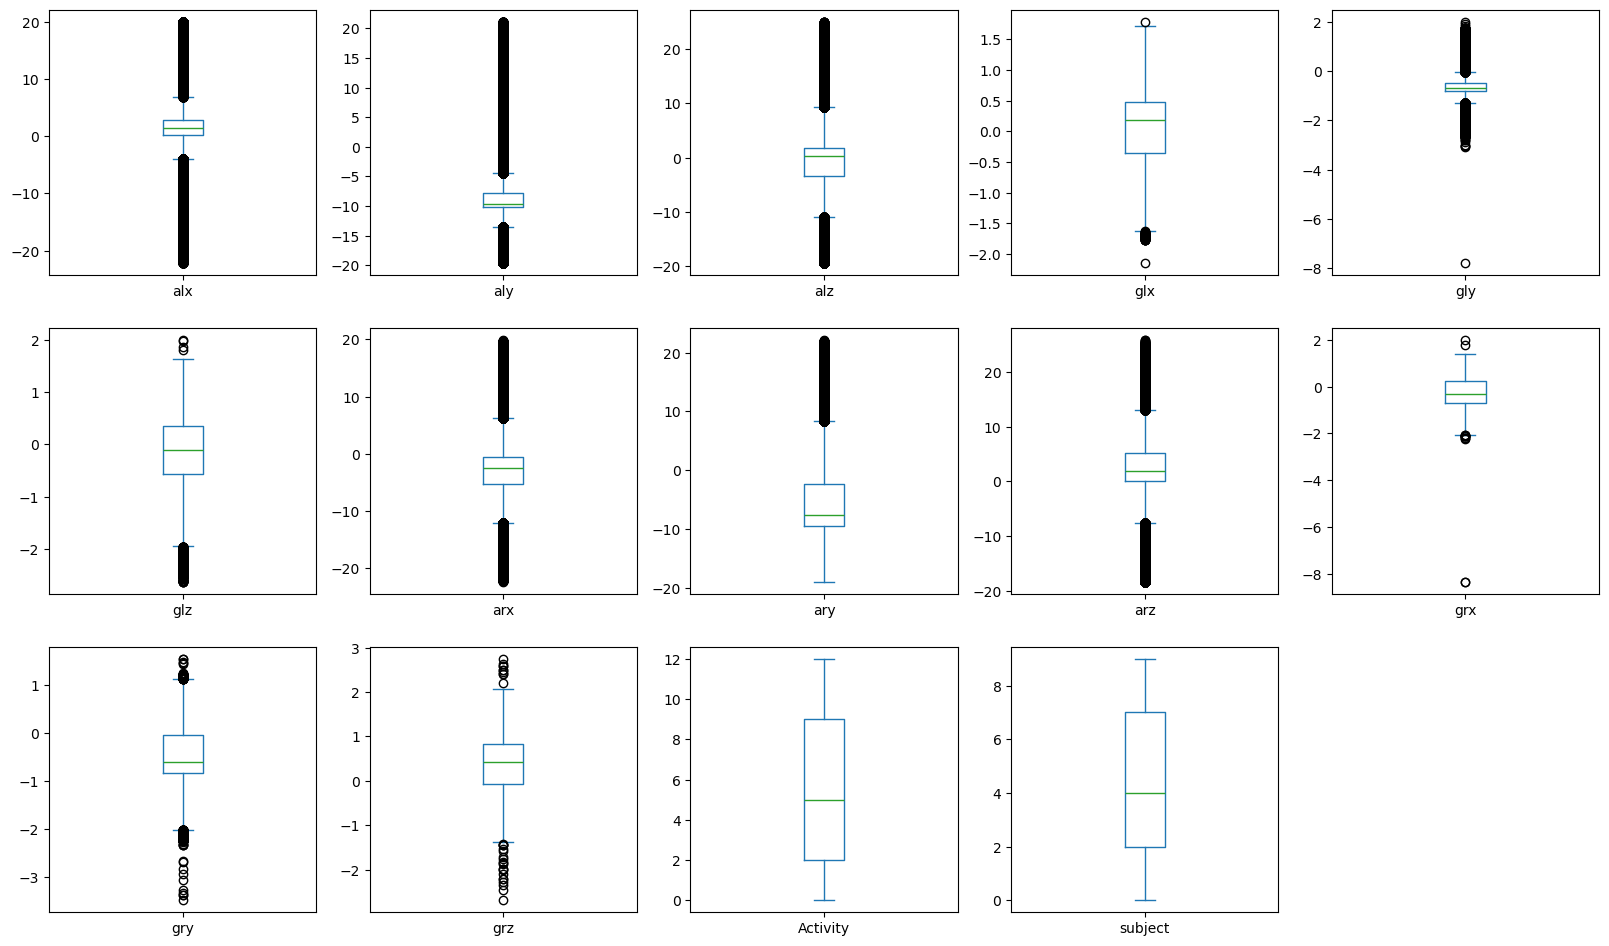

In [12]:
# going back to normal data_frame for this part
le = LabelEncoder()
data_frame['subject'] = le.fit_transform(data_frame['subject'])
data_frame['Activity'] = le.fit_transform(data_frame['Activity'])

# looking at outliers in a giant box plot. layout 5x5 so it actually fits
data_frame.plot(kind='box', subplots=True, layout=(5, 5), figsize=(20, 20))
plt.show()

# train test split time
X = data_frame.drop(['Activity', 'subject'], axis=1) # features only
y = data_frame['Activity'] # target

# 25% for test data, 75% for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# scaler because the sensor numbers are all over the place
r_scaler = RobustScaler()
r_scaler.fit(X_train) 

# scale both test and train sets
X_train_scaled = r_scaler.transform(X_train)
X_test_scaled = r_scaler.transform(X_test)

In [13]:
# helper function so i don't have to copy-paste the print statements 50 times
def result_summarizer(y_true, y_predict, cm_enable=True):
    
    # macro avg is better here since we have multiple classes
    acc = accuracy_score(y_true, y_predict)
    prec = precision_score(y_true, y_predict, average='macro')
    rec = recall_score(y_true, y_predict, average='macro') # sensitivity
    f1 = f1_score(y_true, y_predict, average='macro')
    
    # plot heatmap if cm_enable is true (so it doesn't spam charts in the for loop)
    if cm_enable:
        plt.figure(figsize=(15, 15))
        cm = confusion_matrix(y_true, y_predict)
        
        # using the string labels for ticks instead of numbers
        sns.heatmap(cm, annot=True, cmap="Blues", fmt='g',
                    xticklabels=activity_labels.values, 
                    yticklabels=activity_labels.values)
        
        plt.title("Confusion Matrix")
        plt.show()

    # format prints nicely to 4 decimals
    print(f"Accuracy score: {acc * 100:.4f}%")
    print(f"Precision:      {prec * 100:.4f}%")
    print(f"Recall:         {rec * 100:.4f}%")
    print(f"F1 score:       {f1 * 100:.4f}%\n")

/home/artifex/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Unscaled Train: 0.5517334966387841
LR Unscaled Test: 0.5529807200492698
LR Scaled Train: 0.5516151929741542


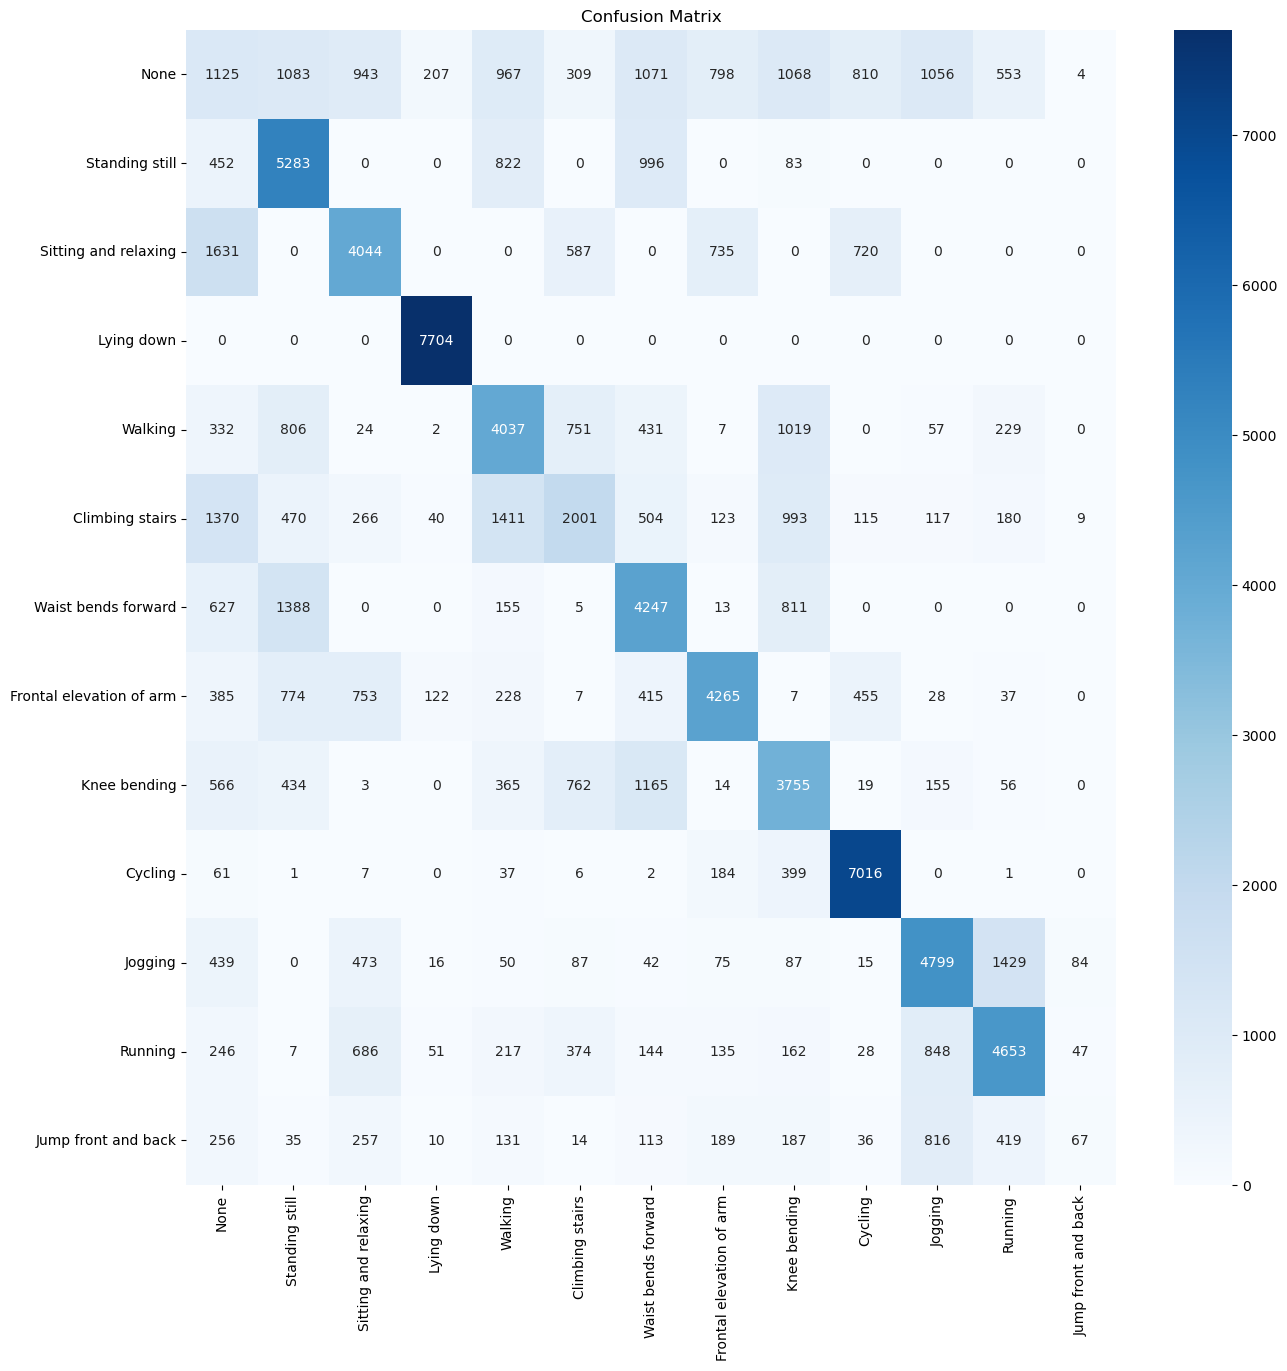

Accuracy score: 55.3200%
Precision:      53.0669%
Recall:         53.6000%
F1 score:       51.9791%



In [14]:
# -- 1. Logistic Regression --

# unscaled first (warning: this takes a minute and the score is trash, like 54%)
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)
print("LR Unscaled Train:", LR.score(X_train, y_train))
print("LR Unscaled Test:", LR.score(X_test, y_test))

# trying scaled data, should be a little better
LR2 = LogisticRegression(max_iter=1000)
LR2.fit(X_train_scaled, y_train)
print("LR Scaled Train:", LR2.score(X_train_scaled, y_train))

# test the scaled model
y_predict_lr = LR2.predict(X_test_scaled)
result_summarizer(y_test, y_predict_lr)

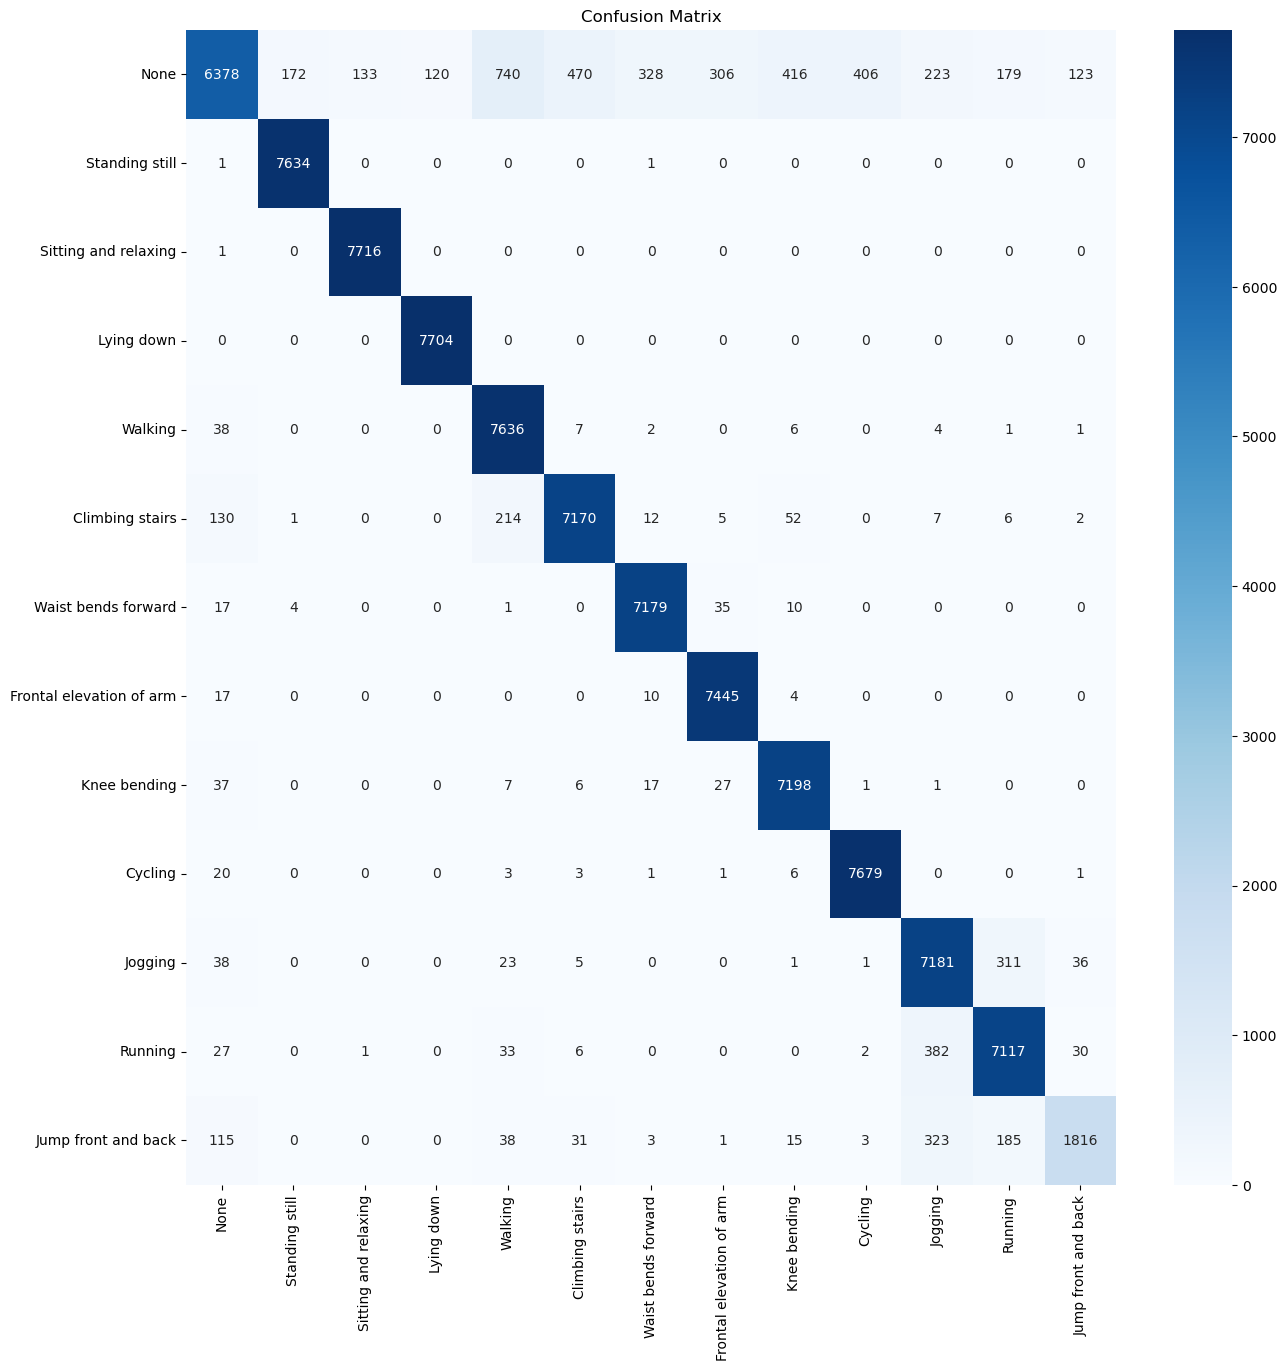

Accuracy score: 93.7933%
Precision:      93.6611%
Recall:         93.4033%
F1 score:       93.1791%

--------------------------------------------------
Number of neighbors = 1

Accuracy score: 93.9477%
Precision:      93.6172%
Recall:         93.7298%
F1 score:       93.5662%

--------------------------------------------------
Number of neighbors = 2

Accuracy score: 92.9394%
Precision:      93.4170%
Recall:         92.0135%
F1 score:       92.4972%

--------------------------------------------------
Number of neighbors = 3

Accuracy score: 94.1847%
Precision:      94.0085%
Recall:         93.9098%
F1 score:       93.7088%

--------------------------------------------------
Number of neighbors = 4

Accuracy score: 93.9947%
Precision:      93.8848%
Recall:         93.4527%
F1 score:       93.3961%

--------------------------------------------------
Number of neighbors = 5

Accuracy score: 93.7933%
Precision:      93.6611%
Recall:         93.4033%
F1 score:       93.1791%

--------------

In [15]:
# -- 2. KNN (K-Nearest Neighbors) --
# video fact: knn is a "lazy learner". trains fast but predicts super slow like an open book test

# trying K=5 first since we already know it works well here
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train_scaled, y_train) 
y_predict_knn1 = knn1.predict(X_test_scaled)

# much better, hits around 88-93%
result_summarizer(y_test, y_predict_knn1)

# loop to test K from 1 to 10 and see if we can beat K=5
for n in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_predict_loop = knn.predict(X_test_scaled)
    
    print("-" * 50)
    print(f"Number of neighbors = {n}\n")
    
    # turning off heatmap for the loop
    result_summarizer(y_test, y_predict_loop, cm_enable=False)

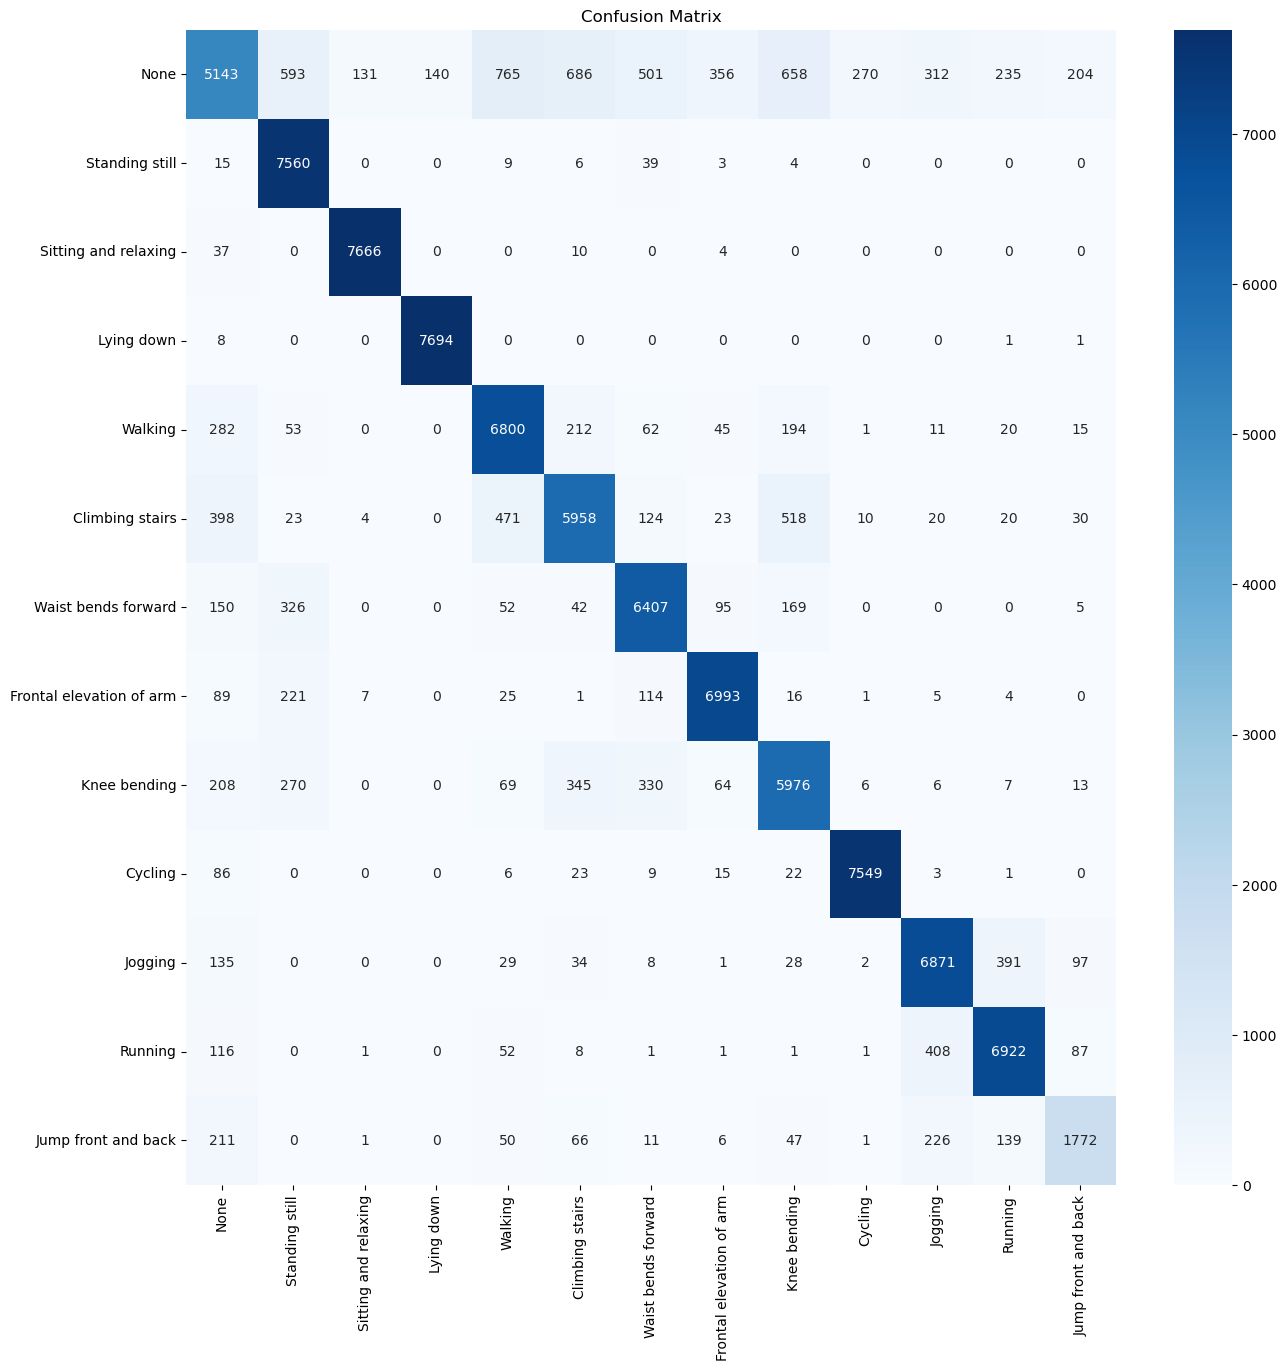

Accuracy score: 86.9644%
Precision:      86.4790%
Recall:         86.9076%
F1 score:       86.4308%



In [16]:
# -- 3. Decision Tree --

# sir said max_depth 14 is already perfectly optimized
DT = DecisionTreeClassifier(max_depth=14)

# using unscaled data here because decision trees don't care about scaling
DT.fit(X_train, y_train) 
y_predict_DT = DT.predict(X_test)

# print out final decision tree results
result_summarizer(y_test, y_predict_DT, cm_enable=True)

# Note: didn't bother doing grid search or random forest because he skipped it at the end